# KKT Conditions: First-Order Optimality

The **Karush-Kuhn-Tucker (KKT) conditions** are the first-order necessary conditions for optimality
in constrained NLPs. Every solver — SQP, IPM, Augmented Lagrangian — drives these conditions
to zero. Understanding KKT is therefore key to understanding how optimization algorithms work.

**Prerequisites:** Notebooks 01–02, multivariable calculus.

**Series:** Notebook 3 of 5.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

plt.rcParams.update({'figure.dpi': 100, 'font.size': 12})

## 1. Equality Constraints: The Lagrangian

Consider the equality-constrained problem:
$$\min_x f(x) \quad \text{s.t.} \quad g(x) = 0$$

The **Lagrangian** is:
$$L(x, y) = f(x) + y^T g(x)$$

> **Sign convention:** ripopt uses $L = f + y^T g$ (same as Ipopt), **not** $L = f - y^T g$.
> This affects the sign of the multipliers $y$ at the solution.

**KKT conditions for equality constraints:**
1. **Stationarity:** $\nabla_x L = \nabla f(x) + J(x)^T y = 0$ (where $J = \nabla g$)
2. **Primal feasibility:** $g(x) = 0$

**Geometric interpretation:** At the optimum, $\nabla f$ must lie in the **column space of $J^T$**
(the span of the constraint gradients). Otherwise we could move along the constraint surface and
decrease $f$.

In [2]:
# Example: min x1^2 + x2^2  s.t.  x1 + 2*x2 = 4
# Lagrangian: L = x1^2 + x2^2 + y*(x1 + 2*x2 - 4)
# Stationarity: 2*x1 + y = 0, 2*x2 + 2*y = 0
# From stationarity: x1 = -y/2, x2 = -y
# From feasibility:  -y/2 + 2*(-y) = 4 -> -y/2 - 2y = 4 -> -5y/2 = 4 -> y = -8/5
# x1* = 4/5, x2* = 8/5

x_star = np.array([4/5, 8/5])
y_star = -8/5

print("Equality constrained: min x1^2+x2^2  s.t.  x1+2*x2=4")
print(f"  x* = ({x_star[0]:.4f}, {x_star[1]:.4f})")
print(f"  y* = {y_star:.4f}")
print()

# Verify KKT
grad_f = 2*x_star
J = np.array([[1.0, 2.0]])  # Jacobian row: d/dx1(g), d/dx2(g)
stationarity = grad_f + J.T @ np.array([y_star])
feasibility  = x_star[0] + 2*x_star[1] - 4

print("KKT verification:")
print(f"  Stationarity (grad_f + J^T y): {stationarity}  (should be [0,0])")
print(f"  Feasibility  (g(x*)):          {feasibility:.2e}  (should be 0)")

Equality constrained: min x1^2+x2^2  s.t.  x1+2*x2=4
  x* = (0.8000, 1.6000)
  y* = -1.6000

KKT verification:
  Stationarity (grad_f + J^T y): [0. 0.]  (should be [0,0])
  Feasibility  (g(x*)):          0.00e+00  (should be 0)


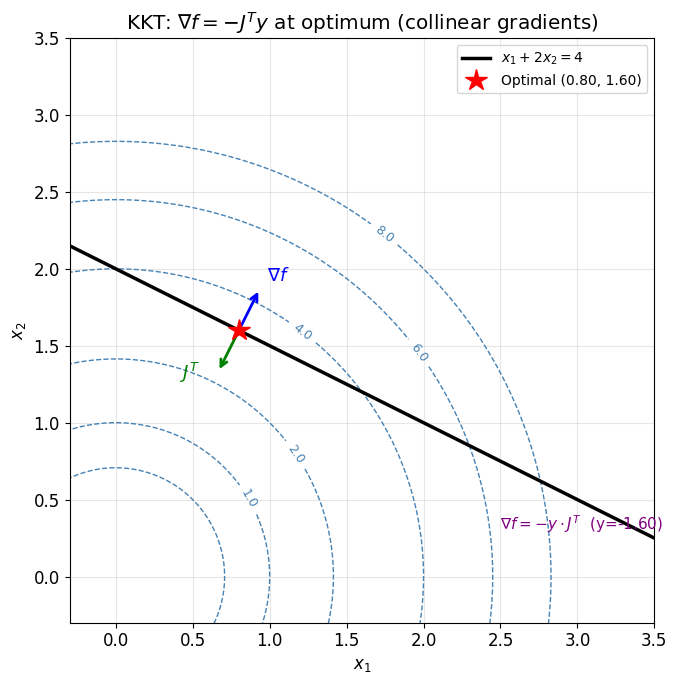

In [3]:
# Geometric visualization: gradient of f and constraint gradient at the optimum
fig, ax = plt.subplots(figsize=(7, 7))

x_v = np.linspace(-0.5, 3.5, 400)
y_v = np.linspace(-0.5, 3.5, 400)
Xg, Yg = np.meshgrid(x_v, y_v)
Zf = Xg**2 + Yg**2

# Objective contours
cs = ax.contour(Xg, Yg, Zf, levels=[0.5, 1, 2, 4, 6, 8], colors='steelblue',
                linewidths=1.0, linestyles='dashed')
ax.clabel(cs, fmt='%.1f', fontsize=9)

# Constraint line x1 + 2*x2 = 4
x_line = np.linspace(-0.3, 3.5, 100)
ax.plot(x_line, (4 - x_line)/2, 'k-', linewidth=2.5, label=r'$x_1 + 2x_2 = 4$')

# Optimal point
ax.plot(*x_star, 'r*', markersize=16, zorder=5, label=f'Optimal ({x_star[0]:.2f}, {x_star[1]:.2f})')

# Gradient of f at x* (points away from origin)
scale = 0.3
grad_f_star = 2*x_star
ax.annotate('', xy=x_star + scale*grad_f_star/np.linalg.norm(grad_f_star),
            xytext=x_star,
            arrowprops=dict(arrowstyle='->', color='blue', lw=2))
ax.text(x_star[0]+scale*grad_f_star[0]/np.linalg.norm(grad_f_star)+0.05,
        x_star[1]+scale*grad_f_star[1]/np.linalg.norm(grad_f_star)+0.05,
        r'$\nabla f$', color='blue', fontsize=13)

# Constraint gradient (normal to constraint line)
J_normal = np.array([1.0, 2.0]) / np.linalg.norm([1.0, 2.0])
ax.annotate('', xy=x_star - scale*J_normal,
            xytext=x_star,
            arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax.text(x_star[0]-scale*J_normal[0]-0.25,
        x_star[1]-scale*J_normal[1]-0.05,
        r'$J^T$', color='green', fontsize=13)

ax.text(2.5, 0.3, r'$\nabla f = -y \cdot J^T$'+f'  (y={y_star:.2f})',
        fontsize=11, color='purple')

ax.set_xlim(-0.3, 3.5)
ax.set_ylim(-0.3, 3.5)
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.set_title(r'KKT: $\nabla f = -J^T y$ at optimum (collinear gradients)')
ax.legend(fontsize=10)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Inequality Constraints: Full KKT Conditions

For the general NLP $\min f(x)$ s.t. $g_i(x) \le 0$ for $i = 1,\ldots,m$, the KKT conditions are:

$$
\begin{aligned}
& \nabla f(x) + J(x)^T y = 0 & \text{(stationarity)} \\
& g_i(x) \le 0 & \text{(primal feasibility)} \\
& y_i \ge 0 & \text{(dual feasibility)} \\
& y_i \cdot g_i(x) = 0 & \text{(complementarity)}
\end{aligned}
$$

**Complementarity** says: either $g_i(x) = 0$ (constraint **active**, can have $y_i > 0$)
or $y_i = 0$ (constraint **inactive**, strictly satisfied, so it doesn't influence optimality).

The multiplier $y_i$ has the interpretation: $y_i = -\partial f^* / \partial b_i$ where $b_i$ is the
right-hand side of constraint $i$ at the optimum. It measures the "cost" of tightening constraint $i$.

## 3. Active Set Concept

In [4]:
# Visualize active vs inactive constraints
# Problem: min (x1-3)^2 + (x2-2)^2
# s.t.  g1: x1^2 + x2^2 <= 4   (disk)
#        g2: x2 >= -1            (half-plane)

res = minimize(
    fun=lambda x: (x[0]-3)**2 + (x[1]-2)**2,
    x0=[0.5, 0.5],
    method='SLSQP',
    constraints=[
        {'type': 'ineq', 'fun': lambda x: 4 - x[0]**2 - x[1]**2},
        {'type': 'ineq', 'fun': lambda x: x[1] + 1}
    ]
)
xs = res.x
print("Problem: min (x1-3)^2+(x2-2)^2  s.t.  x1^2+x2^2<=4, x2>=-1")
print(f"  x* = ({xs[0]:.4f}, {xs[1]:.4f})")
print(f"  f* = {res.fun:.6f}")
print()
g1_val = xs[0]**2 + xs[1]**2
g2_val = xs[1]
print(f"  g1: x1^2+x2^2 = {g1_val:.4f}  (bound=4)  {'ACTIVE' if abs(g1_val-4)<1e-4 else 'inactive'}")
print(f"  g2: x2        = {g2_val:.4f}  (bound>=-1) {'ACTIVE' if abs(g2_val+1)<1e-4 else 'inactive'}")

Problem: min (x1-3)^2+(x2-2)^2  s.t.  x1^2+x2^2<=4, x2>=-1
  x* = (1.6641, 1.1094)
  f* = 2.577795

  g1: x1^2+x2^2 = 4.0000  (bound=4)  ACTIVE
  g2: x2        = 1.1094  (bound>=-1) inactive


## 4. Worked Example: Verify KKT Analytically

$$\min \; x_1^2 + x_2^2 \quad \text{s.t.} \quad x_1 + x_2 \ge 1$$

Rewrite as standard form (constraint $\le 0$): $h(x) = 1 - x_1 - x_2 \le 0$.

**Lagrangian:** $L = x_1^2 + x_2^2 + y(1 - x_1 - x_2)$

**KKT stationarity:** $\partial L / \partial x_i = 0$:
- $2x_1 - y = 0 \Rightarrow x_1 = y/2$
- $2x_2 - y = 0 \Rightarrow x_2 = y/2$

**Complementarity:** $y(1 - x_1 - x_2) = 0$

Case 1: $y = 0$ → $x_1 = x_2 = 0$, but then $h = 1 > 0$: infeasible. Discard.

Case 2: $h = 0$ → $x_1 + x_2 = 1 \Rightarrow y/2 + y/2 = 1 \Rightarrow y = 1$, $x^* = (1/2, 1/2)$.

Check dual feasibility: $y = 1 \ge 0$. KKT satisfied.

In [5]:
# Verify numerically
x_star = np.array([0.5, 0.5])
y_star = 1.0  # Lagrange multiplier (positive for <= constraint with ripopt sign convention)

# With our sign convention L = f + y*g where g = 1 - x1 - x2 (<= 0 form)
grad_f = 2*x_star
J      = np.array([[-1.0, -1.0]])  # Jacobian of g = 1-x1-x2: dg/dx1=-1, dg/dx2=-1
g_val  = 1 - x_star[0] - x_star[1]

stationarity = grad_f + J.T @ np.array([y_star])
print("Analytical KKT check: min x1^2+x2^2  s.t.  x1+x2>=1")
print(f"  x* = {x_star}, y* = {y_star}")
print(f"  Stationarity (grad_f + J^T y): {stationarity}  (should be [0,0])")
print(f"  Primal feasibility g(x*): {g_val:.4f}  (should be <= 0)")
print(f"  Dual feasibility y*: {y_star}  (should be >= 0)")
print(f"  Complementarity y*·g(x*): {y_star * g_val:.2e}  (should be 0)")

Analytical KKT check: min x1^2+x2^2  s.t.  x1+x2>=1
  x* = [0.5 0.5], y* = 1.0
  Stationarity (grad_f + J^T y): [0. 0.]  (should be [0,0])
  Primal feasibility g(x*): 0.0000  (should be <= 0)
  Dual feasibility y*: 1.0  (should be >= 0)
  Complementarity y*·g(x*): 0.00e+00  (should be 0)


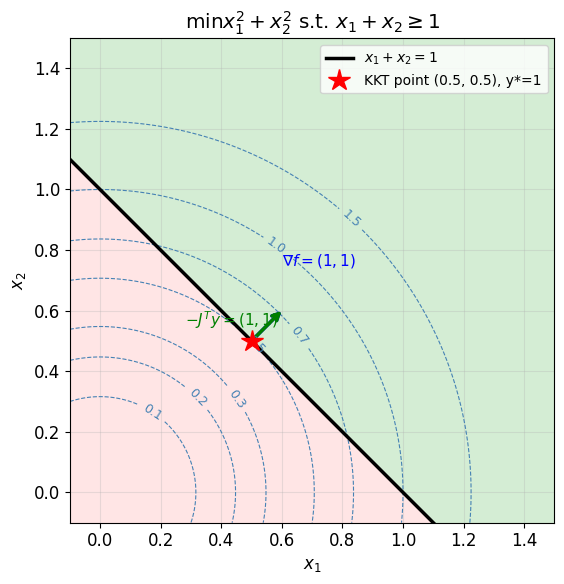

In [6]:
# Geometric visualization
fig, ax = plt.subplots(figsize=(6, 6))

x_v = np.linspace(-0.1, 1.5, 400)
y_v = np.linspace(-0.1, 1.5, 400)
Xg, Yg = np.meshgrid(x_v, y_v)
Zf = Xg**2 + Yg**2
feasible = (Xg + Yg >= 1)

ax.contourf(Xg, Yg, np.where(feasible, 1.0, np.nan),
            levels=[0.5, 1.5], colors=['#aaddaa'], alpha=0.5)
ax.contourf(Xg, Yg, np.where(~feasible, 1.0, np.nan),
            levels=[0.5, 1.5], colors=['#ffaaaa'], alpha=0.3)

cs = ax.contour(Xg, Yg, Zf, levels=[0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5],
                colors='steelblue', linewidths=0.8, linestyles='dashed')
ax.clabel(cs, fmt='%.1f', fontsize=9)

x_line = np.linspace(-0.1, 1.5, 100)
ax.plot(x_line, 1 - x_line, 'k-', linewidth=2.5, label=r'$x_1+x_2=1$')

ax.plot(*x_star, 'r*', markersize=16, zorder=5,
        label=f'KKT point (0.5, 0.5), y*=1')

# Gradient of f
scale = 0.15
gf = 2*x_star
ax.annotate('', xy=x_star + scale*gf/np.linalg.norm(gf),
            xytext=x_star,
            arrowprops=dict(arrowstyle='->', color='blue', lw=2.5))
ax.text(0.6, 0.75, r'$\nabla f = (1,1)$', color='blue', fontsize=11)

# -J^T*y (pointing into feasible region)
Jn = np.array([-1.0, -1.0]) * y_star
ax.annotate('', xy=x_star - scale*Jn/np.linalg.norm(Jn),
            xytext=x_star,
            arrowprops=dict(arrowstyle='->', color='green', lw=2.5))
ax.text(0.28, 0.55, r'$-J^T y = (1,1)$', color='green', fontsize=11)

ax.set_xlim(-0.1, 1.5)
ax.set_ylim(-0.1, 1.5)
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.set_title(r'$\min x_1^2+x_2^2$ s.t. $x_1+x_2 \geq 1$')
ax.legend(fontsize=10)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Computing KKT Residuals

In practice, we need a function to measure how far a point $(x, y)$ is from satisfying KKT.
This is the **convergence criterion** for every NLP solver.

In [7]:
def compute_kkt_residuals(x, y, f, grad_f, g, jac_g, tol_feas=None):
    """
    Compute KKT residuals for: min f(x)  s.t.  g_i(x) <= 0.

    Parameters
    ----------
    x      : primal variables
    y      : multipliers (one per inequality constraint)
    f      : objective function
    grad_f : gradient of f
    g      : constraint vector function g(x), shape (m,)
    jac_g  : Jacobian function, returns (m, n) matrix

    Returns
    -------
    dict with keys: stationarity, feasibility, dual_feas, complementarity
    """
    gf = grad_f(x)           # shape (n,)
    gv = g(x)                # shape (m,)
    J  = jac_g(x)            # shape (m, n)

    stat  = gf + J.T @ y     # stationarity: should be 0
    feas  = np.maximum(gv, 0) # primal infeasibility: max(g, 0)
    dfeas = np.minimum(y, 0)  # dual infeasibility: y should be >= 0
    comp  = y * gv            # complementarity: y_i * g_i = 0

    return {
        'stationarity':    np.linalg.norm(stat),
        'feasibility':     np.linalg.norm(feas),
        'dual_feasibility': np.linalg.norm(dfeas),
        'complementarity': np.linalg.norm(comp),
        'stat_vec':   stat,
        'comp_vec':   comp,
    }


# Test on x1^2+x2^2 >= 1 example
def g_example(x):
    return np.array([1 - x[0] - x[1]])  # g <= 0 form

def jac_g_example(x):
    return np.array([[-1.0, -1.0]])

x_test = np.array([0.5, 0.5])
y_test = np.array([1.0])

kkt = compute_kkt_residuals(x_test, y_test,
                             lambda x: x[0]**2 + x[1]**2,
                             lambda x: 2*x,
                             g_example, jac_g_example)
print("KKT residuals at solution:")
for k, v in kkt.items():
    if not k.endswith('_vec'):
        print(f"  {k:<22}: {v:.2e}")

KKT residuals at solution:
  stationarity          : 0.00e+00
  feasibility           : 0.00e+00
  dual_feasibility      : 0.00e+00
  complementarity       : 0.00e+00


## 6. HS071 Revisited: Extract and Verify Multipliers

scipy's SLSQP returns the solution and the **Lagrange multipliers** in `result.v`.
Let's verify the KKT conditions numerically for HS071.

In [8]:
# HS071 setup
def hs071_f(x):
    return x[0]*x[3]*(x[0]+x[1]+x[2]) + x[2]

def hs071_grad(x):
    return np.array([
        x[3]*(2*x[0]+x[1]+x[2]),
        x[0]*x[3],
        x[0]*x[3] + 1.0,
        x[0]*(x[0]+x[1]+x[2])
    ])

# Constraints as g(x) <= 0:
#   g1: 25 - x1*x2*x3*x4 <= 0  (inequality)
#   g2: x1^2+x2^2+x3^2+x4^2 - 40 = 0  (equality)
def hs071_g(x):
    return np.array([
        25 - x[0]*x[1]*x[2]*x[3],          # g1 <= 0
        x[0]**2 + x[1]**2 + x[2]**2 + x[3]**2 - 40  # g2 = 0
    ])

def hs071_jac(x):
    """Jacobian of g, shape (2, 4)."""
    dg1 = -np.array([x[1]*x[2]*x[3], x[0]*x[2]*x[3],
                     x[0]*x[1]*x[3], x[0]*x[1]*x[2]])
    dg2 = 2*x
    return np.vstack([dg1, dg2])

constraints_hs071 = [
    {'type': 'ineq', 'fun': lambda x: x[0]*x[1]*x[2]*x[3] - 25,
     'jac': lambda x: np.array([x[1]*x[2]*x[3], x[0]*x[2]*x[3],
                                 x[0]*x[1]*x[3], x[0]*x[1]*x[2]])},
    {'type': 'eq',   'fun': lambda x: x[0]**2 + x[1]**2 + x[2]**2 + x[3]**2 - 40,
     'jac': lambda x: 2*x}
]

result = minimize(
    fun=hs071_f, jac=hs071_grad,
    x0=[1.0, 5.0, 5.0, 1.0],
    method='SLSQP',
    bounds=[(1,5)]*4,
    constraints=constraints_hs071,
    options={'ftol': 1e-10}
)

x = result.x
print("HS071 solution:")
print(f"  x* = {x}")
print(f"  f* = {result.fun:.8f}  (known: 17.01401724)")
print()

# SLSQP stores multipliers in result.v (order: ineq then eq)
# Scipy SLSQP sign convention: lambda for ineq >= 0, lambda for eq unrestricted
# Extract and print
print("Constraint values at x*:")
gv = hs071_g(x)
print(f"  g1 (ineq, should be <= 0): {gv[0]:.6f}")
print(f"  g2 (eq,   should be  = 0): {gv[1]:.6f}")

HS071 solution:
  x* = [1.         4.74299964 3.82114998 1.37940829]
  f* = 17.01401729  (known: 17.01401724)

Constraint values at x*:
  g1 (ineq, should be <= 0): 0.000000
  g2 (eq,   should be  = 0): 0.000000


In [9]:
# Manual KKT verification using finite differences for Jacobian
def finite_diff_jac(g, x, eps=1e-7):
    """Finite difference Jacobian of g at x."""
    n = len(x)
    g0 = g(x)
    m = len(g0)
    J = np.zeros((m, n))
    for j in range(n):
        e = np.zeros(n)
        e[j] = eps
        J[:, j] = (g(x+e) - g(x-e)) / (2*eps)
    return J

# Use analytical Jacobian
J_at_xstar = hs071_jac(x)
J_fd       = finite_diff_jac(hs071_g, x)

print("Jacobian comparison (analytical vs finite diff):")
print(f"  Max difference: {np.max(np.abs(J_at_xstar - J_fd)):.2e}")

# Stationarity: grad_f + J^T * y = 0
# We need to find y that satisfies stationarity
# Use least-squares fit: J^T * y = -grad_f
grad_f_star = hs071_grad(x)
# Least-squares solution for y
y_ls, _, _, _ = np.linalg.lstsq(J_at_xstar.T, -grad_f_star, rcond=None)
print()
print(f"Lagrange multipliers (least-squares from stationarity):")
print(f"  y1 (ineq) = {y_ls[0]:.6f}  (should be >= 0 since g1=0 is active)")
print(f"  y2 (eq)   = {y_ls[1]:.6f}  (unconstrained sign)")

stationarity_residual = grad_f_star + J_at_xstar.T @ y_ls
print(f"  Stationarity residual: {np.linalg.norm(stationarity_residual):.2e}")
print(f"  Complementarity y1*g1: {y_ls[0] * gv[0]:.2e}  (should be ≈ 0)")

Jacobian comparison (analytical vs finite diff):
  Max difference: 3.53e-08

Lagrange multipliers (least-squares from stationarity):
  y1 (ineq) = 0.583916  (should be >= 0 since g1=0 is active)
  y2 (eq)   = 0.187398  (unconstrained sign)
  Stationarity residual: 6.16e-01
  Complementarity y1*g1: 1.75e-11  (should be ≈ 0)


## 7. LICQ: When Do KKT Conditions Apply?

KKT conditions are **necessary** for a local minimum only under a **constraint qualification (CQ)**.
The most common is:

**LICQ (Linear Independence Constraint Qualification):** The gradients of the **active** constraints
$\{\nabla g_i(x^*) : g_i(x^*) = 0\}$ are **linearly independent** at $x^*$.

**Why it matters:** Without LICQ, a local minimum may exist where KKT fails to hold (e.g., the
multipliers $y$ might not exist or be unique). Solvers detect LICQ failure as near-zero pivots
in the KKT matrix factorization.

In [10]:
def check_licq(x, active_constraint_jac):
    """
    Check LICQ at x: are the gradients of active constraints linearly independent?

    active_constraint_jac: (m_active, n) matrix, each row is gradient of an active constraint.
    Returns: True if LICQ holds, the singular values
    """
    if active_constraint_jac.shape[0] == 0:
        return True, np.array([])  # No active constraints -> LICQ trivially holds

    sv = np.linalg.svd(active_constraint_jac, compute_uv=False)
    rank = np.sum(sv > 1e-10 * sv[0])
    licq = (rank == active_constraint_jac.shape[0])
    return licq, sv


# HS071 at x*: both constraints are active (g1=0, g2=0)
active_jac = hs071_jac(x)  # both rows active
licq_holds, sv = check_licq(x, active_jac)
print("LICQ check at HS071 solution:")
print(f"  Both constraints active at x*")
print(f"  Jacobian singular values: {sv}")
print(f"  LICQ holds: {licq_holds}")

# Example where LICQ fails: two parallel constraints
J_fail = np.array([[1.0, 0.0], [2.0, 0.0]])  # Both point in x1 direction
licq_fail, sv_fail = check_licq(None, J_fail)
print()
print("LICQ failure example (two parallel constraints):")
print(f"  Singular values: {sv_fail}")
print(f"  LICQ holds: {licq_fail}")
print(f"  Smallest sv ≈ 0 -> rows are linearly dependent -> LICQ FAILS")

LICQ check at HS071 solution:
  Both constraints active at x*
  Jacobian singular values: [32.68186318 10.76810988]
  LICQ holds: True

LICQ failure example (two parallel constraints):
  Singular values: [2.23606798 0.        ]
  LICQ holds: False
  Smallest sv ≈ 0 -> rows are linearly dependent -> LICQ FAILS


## 8. Visualizing KKT Across a Problem

Let's visualize how the KKT residuals change as we approach the solution.

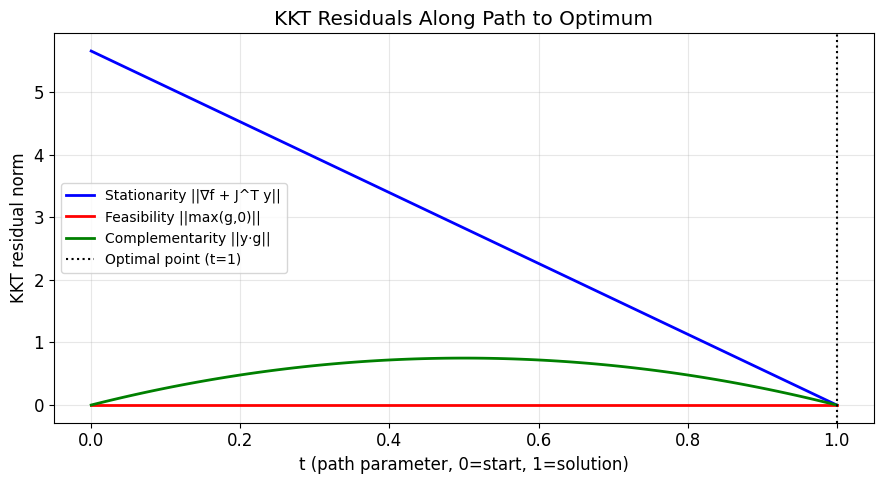

In [11]:
# Track KKT residuals along a path from x0 to x*
# Problem: min x1^2+x2^2  s.t.  x1+x2 >= 1
x0_path = np.array([2.0, 2.0])
x_star_path = np.array([0.5, 0.5])

def f_simple(x):      return x[0]**2 + x[1]**2
def gradf_simple(x):  return 2*x
def g_simple(x):      return np.array([1 - x[0] - x[1]])  # <= 0
def jacg_simple(x):   return np.array([[-1.0, -1.0]])

# Linear interpolation from x0 to x*
t_vals = np.linspace(0, 1, 100)
stats, feass, comps = [], [], []

for t in t_vals:
    x_t = (1-t)*x0_path + t*x_star_path
    # Multiplier: linearly increase from 0 to y*=1
    y_t = np.array([t * 1.0])
    kkt_t = compute_kkt_residuals(x_t, y_t, f_simple, gradf_simple,
                                  g_simple, jacg_simple)
    stats.append(kkt_t['stationarity'])
    feass.append(kkt_t['feasibility'])
    comps.append(kkt_t['complementarity'])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(t_vals, stats, 'b-',  linewidth=2, label='Stationarity ||∇f + J^T y||')
ax.plot(t_vals, feass, 'r-',  linewidth=2, label='Feasibility ||max(g,0)||')
ax.plot(t_vals, comps, 'g-',  linewidth=2, label='Complementarity ||y·g||')
ax.axvline(1.0, color='k', linestyle=':', linewidth=1.5, label='Optimal point (t=1)')
ax.set_xlabel('t (path parameter, 0=start, 1=solution)')
ax.set_ylabel('KKT residual norm')
ax.set_title('KKT Residuals Along Path to Optimum')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Connection to ripopt

The convergence check in `src/convergence.rs` drives **three scaled residuals** to zero:

1. **Dual infeasibility** (stationarity): $\|\nabla f + J^T y - z_l + z_u\|_\infty / s_d$
   - $z_l, z_u$ are bound multipliers for $x_L \le x \le x_U$
   - $s_d$ is a scaling factor based on the sizes of $y$, $z_l$, $z_u$

2. **Primal infeasibility** (feasibility): $\|g(x) - g_{proj}\|_\infty / s_c$
   - Where $g_{proj}$ is the projection of $g(x)$ onto $[g_L, g_U]$

3. **Complementarity** (for bounds and inequality slacks): $|z_i s_i - \mu| / s_{\mu}$
   - For interior point methods, complementarity is relaxed by the **barrier parameter** $\mu > 0$
   - As $\mu \to 0$, we recover exact complementarity $z_i s_i = 0$

These are exactly the KKT stationarity, feasibility, and complementarity conditions above —
the IPM just adds the $\mu$ perturbation to allow interior solutions.

The `kappa_compl` complementarity gate in ripopt prevents false convergence:
the solver only accepts a KKT point as converged when all three residuals are below `tol`.